# **AI-powered Behavioral Analysis for Mental Health Crisis Detection — Midterm Report**
**Author:** Yixing Fan  
**Date:** July 2025  

## **1. Project Overview**
This project is part of **Google Summer of Code 2025** with **HumanAI**.  
The goal is to explore how **Natural Language Processing (NLP)** can be applied to detect early signs of **suicidal ideation** in online text, particularly Reddit posts.  

So far, I have built a pipeline that:
- **Collected and cleaned** mental health-related text data from Reddit, combined with an existing labeled dataset.
- **Fine-tuned a BERT model** to classify whether a post indicates suicidal intent.
- **Built initial analysis tools**, including a **word bank** (frequent terms in suicidal posts) and **word cloud visualizations**.
- **Performed sentiment and risk-level analysis** using VADER sentiment scoring and keyword-based risk detection.
- **Created a test script (`predict.py`)** to analyze new text samples.
- **Added Google Trends analysis** for mental health keywords.

Initial experiments show that the BERT-based model achieves strong results (accuracy ~94%, F1-score ~0.97) in distinguishing between suicidal and non-suicidal content.


## **2. Dataset & Preprocessing**
Below we display some examples from the preprocessed Reddit dataset (`filtered_reddit_posts.csv`).

In [1]:
import pandas as pd
df = pd.read_csv('output/filtered_reddit_posts.csv')
df.head(5)

,id,timestamp,subreddit,cleaned_text,upvotes,comments,url
0,doqwow,1.572361e+09,depression,mostbroken leastunderstood rules helpers may i...,2366,177,https://www.reddit.com/r/depression/comments/d...
1,1lfgnxr,1.750354e+09,depression,even depression seeing reality clearly world f...,32,12,https://www.reddit.com/r/depression/comments/1...
2,1lfirj8,1.750359e+09,depression,clear sign person struggling depression someon...,18,14,https://www.reddit.com/r/depression/comments/1...
3,1lfkhld,1.750363e+09,depression,dumb make depressed envy smart people intellig...,6,7,https://www.reddit.com/r/depression/comments/1...
4,1lfjihf,1.750361e+09,depression,feels like im existing living ive struggled ma...,6,0,https://www.reddit.com/r/depression/comments/1...


## **3. Word Bank & Word Cloud**
We generated a word bank and visualized the frequent terms in suicidal posts.

In [2]:
word_bank = pd.read_csv('output/word_bank.csv')
word_bank.head(10)

,word,frequency
0,want,819
1,life,589
2,kill,406
3,die,386
4,suicide,385
5,people,345
6,feel,334
7,will,313
8,going,309
9,anymore,281


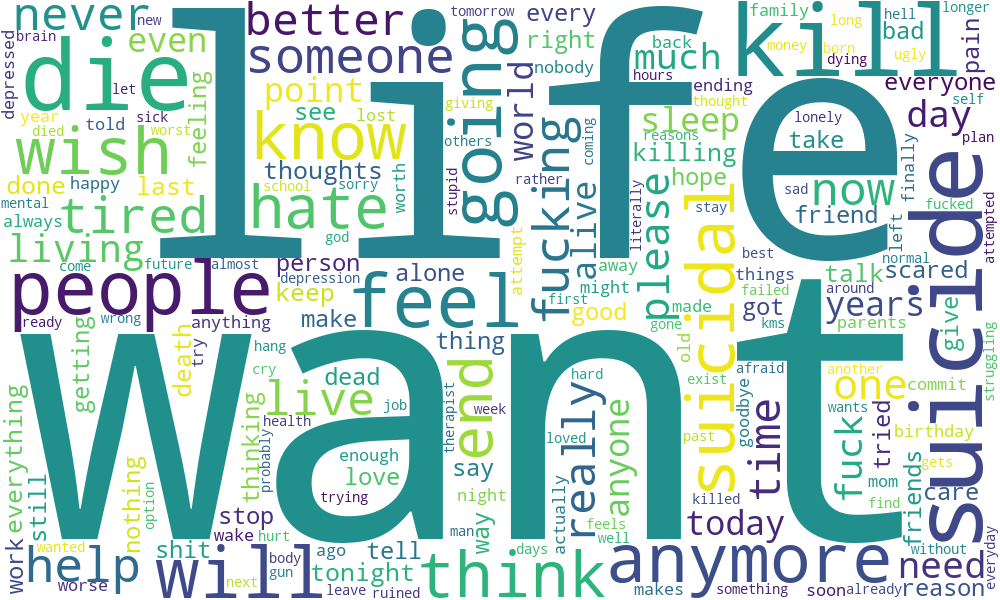

In [3]:
from IPython.display import Image
Image(filename='output/mental_health_wordcloud.png')


## **4. Google Trends Analysis**
A visualization of mental health keyword search trends.

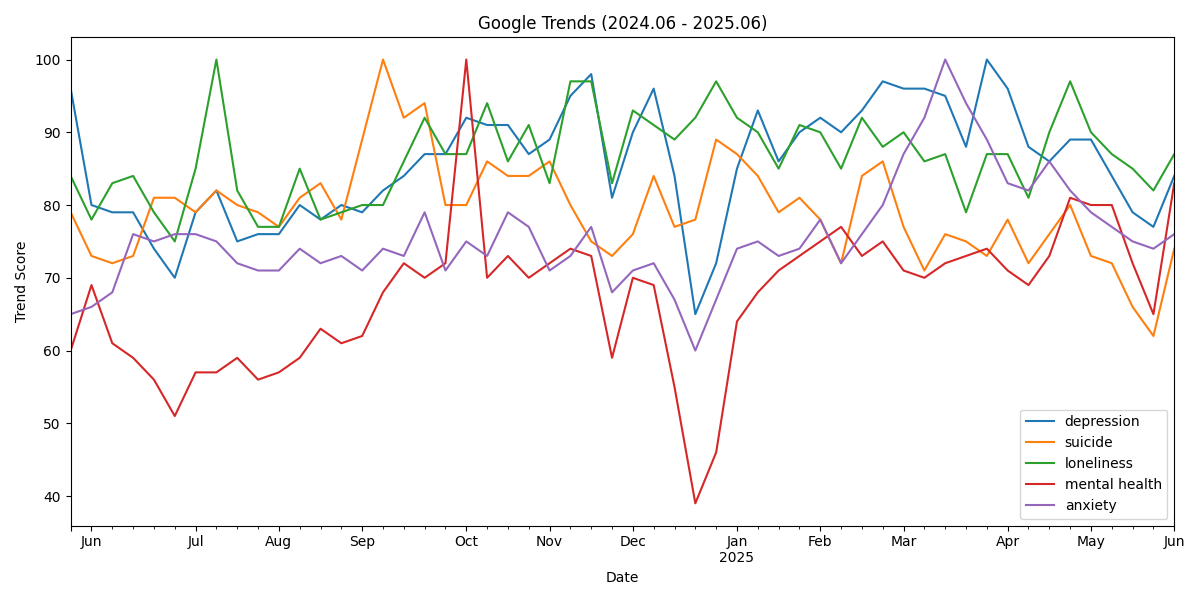

In [4]:
Image(filename='output/google_trends_plot.png')

## **5. BERT Model Results**
We fine-tuned a BERT model (`bert-base-uncased`) on the dataset. Below are the evaluation metrics.

In [5]:
import json
with open('results/evaluation_results.json', 'r') as f:
    eval_results = json.load(f)
eval_results

{'eval_loss': 0.19684794545173645,
 'eval_runtime': 349.1911,
 'eval_samples_per_second': 4.081,
 'eval_steps_per_second': 0.513,
 'epoch': 0.3119151590767311}

## **6. Prediction Demo**
Let's use our model to classify new text samples.

In [7]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained("./results/final_model")
model = BertForSequenceClassification.from_pretrained("./results/final_model")
model.eval()

def predict_text(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=1).item()
    return "Suicidal" if prediction == 1 else "Non-suicidal"

predict_text("I feel hopeless and want to end it all.")


'Suicidal'

In [8]:
predict_text("Today is a good day.")

'Non-suicidal'

## **7. Conclusion & Next Steps**
- Improve BERT model performance with hyperparameter tuning and more training epochs.
- Add multi-class emotion detection.
- Expand dataset using additional annotated sources.
- Enhance visualizations and build an interactive dashboard.
